# Model genetische diversiteit

## Packages inladen

In [1]:
import pathlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import (
    train_test_split, cross_val_score, GroupKFold,
)

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.inspection import permutation_importance

sns.set_theme(style="whitegrid")

## Data inladen 

### Dataframe van Aquamaps en Bio-ORACLE

Deze data is afkomstig van Aquamaps

In [2]:
df_env = pd.read_csv("Data/Diversity_data_with_env.csv")
print(f"env data:             {df_env.shape}")
df_env.head()

env data:             (2452, 33)


,grid_id,long,lat,marine_species_richness,PD,co1_genetic_diversity_mean,long_deg,lat_deg,long_dd,lat_dd,...,Shelf,Slope,Abyssal,TidalRange,Coral,Estuary,Seamount,MPA,matched_CenterLong,matched_CenterLat
0,1,-17174579,-7123536,44,11.830844,0.007171,-171.74579,-71.23536,-171.74579,-71.23536,...,0.0,730.228795,263.361205,-9999.0,0.0,0.0,0,NaN,-171.75,-71.25
1,2,-16788679,-7123536,43,11.830844,0.007171,-167.88679,-71.23536,-167.88679,-71.23536,...,0.0,0.000000,993.590000,-9999.0,0.0,0.0,0,NaN,-167.75,-71.25
2,3,-16402779,-7123536,44,12.650381,0.007499,-164.02779,-71.23536,-164.02779,-71.23536,...,0.0,0.000000,993.590000,-9999.0,0.0,0.0,0,NaN,-164.25,-71.25
3,4,-16016879,-7123536,44,12.650381,0.007499,-160.16879,-71.23536,-160.16879,-71.23536,...,0.0,0.000000,993.590000,-9999.0,0.0,0.0,0,NaN,-160.25,-71.25
4,5,-15630979,-7123536,45,12.650381,0.007499,-156.30979,-71.23536,-156.30979,-71.23536,...,0.0,0.000000,993.590000,-9999.0,0.0,0.0,0,NaN,-156.25,-71.25


Deze data is afkomstig van Bio-ORACLE

In [3]:
df_biooracle = pd.read_csv("Data/Diversity_data_with_biooracle_2010.csv")
print(f"biooracle data:       {df_biooracle.shape}")
df_biooracle.head()

biooracle data:       (2452, 75)


,marine_species_richness,PD,co1_genetic_diversity_mean,long_deg,lat_deg,chl_max,chl_mean,chl_min,clt_max,clt_mean,...,terrain_characteristics_bea_min,terrain_characteristics_rug,terrain_characteristics_slope,terrain_characteristics_topo,T_ltmax,T_ltmin,T_max,T_mean,T_min,T_range
0,44,11.830844,0.007171,-171.74579,-71.23536,1.987486,0.264222,0.015311,0.993542,0.681597,...,-3883.0,66.347260,0.933108,6.854279,-0.711044,-1.904281,-0.127859,-1.602750,-1.977225,1.849366
1,43,11.830844,0.007171,-167.88679,-71.23536,2.205368,0.278952,0.015232,0.961121,0.693978,...,-4084.0,21.055542,0.320794,-12.930603,-0.847708,-1.925544,-0.017505,-1.620118,-2.000000,1.988636
2,44,12.650381,0.007499,-164.02779,-71.23536,1.891105,0.270836,0.015052,0.960210,0.698352,...,-4153.0,14.489563,0.228825,5.524109,-0.521772,-1.923338,0.125601,-1.582915,-2.000000,2.137620
3,44,12.650381,0.007499,-160.16879,-71.23536,1.963815,0.293940,0.015424,0.962838,0.693123,...,-4303.0,4.413208,0.081748,1.760254,-0.558407,-1.909406,-0.032617,-1.579760,-1.976150,1.943533
4,45,12.650381,0.007499,-156.30979,-71.23536,1.956123,0.298378,0.015726,0.969080,0.688964,...,-4341.0,10.302124,0.234018,-0.892456,-0.570859,-1.906482,-0.000029,-1.570748,-2.000000,2.001978


### Variabelen bekijken

In [69]:
df_biooracle.columns

Index(['marine_species_richness', 'PD', 'co1_genetic_diversity_mean',
       'long_deg', 'lat_deg', 'chl_max', 'chl_mean', 'chl_min', 'clt_max',
       'clt_mean', 'clt_min', 'currentdirection_max', 'currentdirection_mean',
       'currentdirection_min', 'currentvelocity_ltmax', 'currentvelocity_max',
       'currentvelocity_mean', 'currentvelocity_min', 'dfe_max', 'dfe_mean',
       'dfe_min', 'kdpar_max', 'kdpar_mean', 'kdpar_min', 'mlotst_max',
       'mlotst_mean', 'mlotst_min', 'no3_max', 'no3_mean', 'no3_min', 'o2_max',
       'o2_mean', 'o2_min', 'par_mean', 'par_min', 'phyc_max', 'phyc_mean',
       'phyc_min', 'ph_max', 'ph_mean', 'ph_min', 'po4_max', 'po4_mean',
       'po4_min', 'salinity_ltmax', 'salinity_ltmin', 'salinity_max',
       'salinity_mean', 'salinity_min', 'salinity_range', 'siconc_max',
       'siconc_mean', 'siconc_min', 'sithick_max', 'sithick_mean',
       'sithick_min', 'si_max', 'si_mean', 'si_min', 'tas_max', 'tas_mean',
       'tas_min', 'terrain_charact

In [70]:
df_env.columns

Index(['grid_id', 'long', 'lat', 'marine_species_richness', 'PD',
       'co1_genetic_diversity_mean', 'long_deg', 'lat_deg', 'long_dd',
       'lat_dd', 'DepthMin', 'DepthMax', 'DepthMean', 'ClimZoneCode',
       'SSTAnMean', 'SBTAnMean', 'SalinityMean', 'SalinityBMean',
       'PrimProdMean', 'IceConAnn', 'OxyMean', 'OxyBMean', 'LandDist', 'Shelf',
       'Slope', 'Abyssal', 'TidalRange', 'Coral', 'Estuary', 'Seamount', 'MPA',
       'matched_CenterLong', 'matched_CenterLat'],
      dtype='object')

### Beide datasets samenvoegen obv locatie (longitude en latitude)


In [71]:
df_merge = pd.merge(df_env, df_biooracle, on = ["long_deg", "lat_deg"], how = "inner")
print(f"merged data:             {df_merge.shape}")
df_merge.head()

merged data:             (2452, 106)


,grid_id,long,lat,marine_species_richness_x,PD_x,co1_genetic_diversity_mean_x,long_deg,lat_deg,long_dd,lat_dd,...,terrain_characteristics_bea_min,terrain_characteristics_rug,terrain_characteristics_slope,terrain_characteristics_topo,T_ltmax,T_ltmin,T_max,T_mean,T_min,T_range
0,1,-17174579,-7123536,44,11.830844,0.007171,-171.74579,-71.23536,-171.74579,-71.23536,...,-3883.0,66.347260,0.933108,6.854279,-0.711044,-1.904281,-0.127859,-1.602750,-1.977225,1.849366
1,2,-16788679,-7123536,43,11.830844,0.007171,-167.88679,-71.23536,-167.88679,-71.23536,...,-4084.0,21.055542,0.320794,-12.930603,-0.847708,-1.925544,-0.017505,-1.620118,-2.000000,1.988636
2,3,-16402779,-7123536,44,12.650381,0.007499,-164.02779,-71.23536,-164.02779,-71.23536,...,-4153.0,14.489563,0.228825,5.524109,-0.521772,-1.923338,0.125601,-1.582915,-2.000000,2.137620
3,4,-16016879,-7123536,44,12.650381,0.007499,-160.16879,-71.23536,-160.16879,-71.23536,...,-4303.0,4.413208,0.081748,1.760254,-0.558407,-1.909406,-0.032617,-1.579760,-1.976150,1.943533
4,5,-15630979,-7123536,45,12.650381,0.007499,-156.30979,-71.23536,-156.30979,-71.23536,...,-4341.0,10.302124,0.234018,-0.892456,-0.570859,-1.906482,-0.000029,-1.570748,-2.000000,2.001978


In [72]:
df_merge.columns

Index(['grid_id', 'long', 'lat', 'marine_species_richness_x', 'PD_x',
       'co1_genetic_diversity_mean_x', 'long_deg', 'lat_deg', 'long_dd',
       'lat_dd',
       ...
       'terrain_characteristics_bea_min', 'terrain_characteristics_rug',
       'terrain_characteristics_slope', 'terrain_characteristics_topo',
       'T_ltmax', 'T_ltmin', 'T_max', 'T_mean', 'T_min', 'T_range'],
      dtype='object', length=106)

 data verwijderen die onnodig is: meerdere keren coördinaten, andere biodiversiteitsmaten, enkel gemiddeldes overhouden

In [73]:
cols_to_drop = (df_merge.filter(regex=r'(?i)(min|max|range)').columns.tolist() + ["PD_x", "PD_y","marine_species_richness_x", "marine_species_richness_y", "grid_id", "long", "lat", "long_dd", "lat_dd","MPA"])
df_merge = df_merge.drop(cols_to_drop, axis = 1)
df_merge.head()

,co1_genetic_diversity_mean_x,long_deg,lat_deg,DepthMean,ClimZoneCode,SSTAnMean,SBTAnMean,SalinityMean,SalinityBMean,PrimProdMean,...,siconc_mean,sithick_mean,si_mean,tas_mean,terrain_characteristics_aspect,terrain_characteristics_bea_mean,terrain_characteristics_rug,terrain_characteristics_slope,terrain_characteristics_topo,T_mean
0,0.007171,-171.74579,-71.23536,3998,SP,-1.693377,-0.049802,33.934307,34.705566,1.153,...,0.731921,0.682407,103.700478,-12.067131,10.920937,-3936.972168,66.347260,0.933108,6.854279,-1.602750
1,0.007171,-167.88679,-71.23536,4079,SP,-1.697129,-0.070504,33.976231,34.703896,1.141,...,0.727964,0.742742,104.054313,-11.786772,141.201179,-4093.388916,21.055542,0.320794,-12.930603,-1.620118
2,0.007499,-164.02779,-71.23536,4185,SP,-1.658674,-0.071121,33.934555,34.703419,1.120,...,0.693648,0.713952,102.867443,-11.387081,216.269828,-4160.611328,14.489563,0.228825,5.524109,-1.582915
3,0.007499,-160.16879,-71.23536,4231,SP,-1.629549,-0.072501,33.875896,34.703423,1.169,...,0.693803,0.720227,99.723148,-10.962065,224.836870,-4305.361328,4.413208,0.081748,1.760254,-1.579760
4,0.007499,-156.30979,-71.23536,4322,SP,-1.620574,-0.066624,33.789886,34.710335,1.094,...,0.687315,0.703112,97.156055,-10.534314,300.267603,-4353.527832,10.302124,0.234018,-0.892456,-1.570748


### Categorische variabele encoderen als numerieke variabele

In [74]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

categorical_cols = df_merge.select_dtypes(include="object").columns

for col in categorical_cols:
    df_merge[col] = le.fit_transform(df_merge[col].astype(str))


In [75]:
df_merge.head()

,co1_genetic_diversity_mean_x,long_deg,lat_deg,DepthMean,ClimZoneCode,SSTAnMean,SBTAnMean,SalinityMean,SalinityBMean,PrimProdMean,...,siconc_mean,sithick_mean,si_mean,tas_mean,terrain_characteristics_aspect,terrain_characteristics_bea_mean,terrain_characteristics_rug,terrain_characteristics_slope,terrain_characteristics_topo,T_mean
0,0.007171,-171.74579,-71.23536,3998,5,-1.693377,-0.049802,33.934307,34.705566,1.153,...,0.731921,0.682407,103.700478,-12.067131,10.920937,-3936.972168,66.347260,0.933108,6.854279,-1.602750
1,0.007171,-167.88679,-71.23536,4079,5,-1.697129,-0.070504,33.976231,34.703896,1.141,...,0.727964,0.742742,104.054313,-11.786772,141.201179,-4093.388916,21.055542,0.320794,-12.930603,-1.620118
2,0.007499,-164.02779,-71.23536,4185,5,-1.658674,-0.071121,33.934555,34.703419,1.120,...,0.693648,0.713952,102.867443,-11.387081,216.269828,-4160.611328,14.489563,0.228825,5.524109,-1.582915
3,0.007499,-160.16879,-71.23536,4231,5,-1.629549,-0.072501,33.875896,34.703423,1.169,...,0.693803,0.720227,99.723148,-10.962065,224.836870,-4305.361328,4.413208,0.081748,1.760254,-1.579760
4,0.007499,-156.30979,-71.23536,4322,5,-1.620574,-0.066624,33.789886,34.710335,1.094,...,0.687315,0.703112,97.156055,-10.534314,300.267603,-4353.527832,10.302124,0.234018,-0.892456,-1.570748


### Dubbele kolommen verwijderen

In [76]:
df_merge = df_merge.T.drop_duplicates().T
df_merge = df_merge.rename(columns={"co1_genetic_diversity_mean_x": "co1_genetic_diversity_mean"})
df_merge.head()

,co1_genetic_diversity_mean,long_deg,lat_deg,DepthMean,ClimZoneCode,SSTAnMean,SBTAnMean,SalinityMean,SalinityBMean,PrimProdMean,...,siconc_mean,sithick_mean,si_mean,tas_mean,terrain_characteristics_aspect,terrain_characteristics_bea_mean,terrain_characteristics_rug,terrain_characteristics_slope,terrain_characteristics_topo,T_mean
0,0.007171,-171.74579,-71.23536,3998.0,5.0,-1.693377,-0.049802,33.934307,34.705566,1.153,...,0.731921,0.682407,103.700478,-12.067131,10.920937,-3936.972168,66.347260,0.933108,6.854279,-1.602750
1,0.007171,-167.88679,-71.23536,4079.0,5.0,-1.697129,-0.070504,33.976231,34.703896,1.141,...,0.727964,0.742742,104.054313,-11.786772,141.201179,-4093.388916,21.055542,0.320794,-12.930603,-1.620118
2,0.007499,-164.02779,-71.23536,4185.0,5.0,-1.658674,-0.071121,33.934555,34.703419,1.120,...,0.693648,0.713952,102.867443,-11.387081,216.269828,-4160.611328,14.489563,0.228825,5.524109,-1.582915
3,0.007499,-160.16879,-71.23536,4231.0,5.0,-1.629549,-0.072501,33.875896,34.703423,1.169,...,0.693803,0.720227,99.723148,-10.962065,224.836870,-4305.361328,4.413208,0.081748,1.760254,-1.579760
4,0.007499,-156.30979,-71.23536,4322.0,5.0,-1.620574,-0.066624,33.789886,34.710335,1.094,...,0.687315,0.703112,97.156055,-10.534314,300.267603,-4353.527832,10.302124,0.234018,-0.892456,-1.570748


In [77]:
df_merge.columns

Index(['co1_genetic_diversity_mean', 'long_deg', 'lat_deg', 'DepthMean',
       'ClimZoneCode', 'SSTAnMean', 'SBTAnMean', 'SalinityMean',
       'SalinityBMean', 'PrimProdMean', 'IceConAnn', 'OxyMean', 'OxyBMean',
       'LandDist', 'Shelf', 'Slope', 'Abyssal', 'Coral', 'Estuary', 'Seamount',
       'matched_CenterLong', 'matched_CenterLat', 'chl_mean', 'clt_mean',
       'currentdirection_mean', 'currentvelocity_mean', 'dfe_mean',
       'kdpar_mean', 'mlotst_mean', 'no3_mean', 'o2_mean', 'par_mean',
       'phyc_mean', 'ph_mean', 'po4_mean', 'salinity_mean', 'siconc_mean',
       'sithick_mean', 'si_mean', 'tas_mean', 'terrain_characteristics_aspect',
       'terrain_characteristics_bea_mean', 'terrain_characteristics_rug',
       'terrain_characteristics_slope', 'terrain_characteristics_topo',
       'T_mean'],
      dtype='object')

## Data exploratie

### Distributie van de doelvariabele

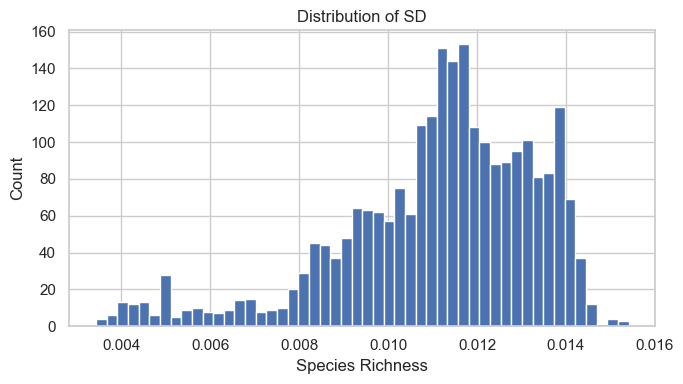

In [50]:
target = "co1_genetic_diversity_mean"
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(df_merge[target], bins=50, edgecolor="white")
ax.set_xlabel("Species Richness")
ax.set_ylabel("Count")
ax.set_title("Distribution of SD")
plt.tight_layout()
plt.show()

### Correlatie berekenen
Variabelen t.o.v. target

In [51]:
corr_to_target = df_merge.corr(method = "pearson")[target].drop(labels = [target]) #correlatie berekenen van alle variabelen tov target en correlatie target met zichzelf laten vallen (is toch gelijk aan 1)
top = corr_to_target.reindex(corr_to_target.abs().sort_values(ascending=False).index) #sorteer van hoog naar laag
top.head(10)

tas_mean       0.828179
OxyMean       -0.805125
o2_mean       -0.801597
SSTAnMean      0.796844
T_mean         0.796517
clt_mean      -0.690056
par_mean       0.664754
IceConAnn     -0.647700
po4_mean      -0.646589
siconc_mean   -0.641711
Name: co1_genetic_diversity_mean, dtype: float64

variabelen t.o.v. elkaar

In [52]:
corr = df_merge.corr(numeric_only=True)

# corr omzetten naar lijst van paren
corr_pairs = corr.abs().unstack()

# zelf-correlaties verwijderen
corr_pairs = corr_pairs[corr_pairs < 1]

# top 10
top_pairs = corr_pairs.sort_values(ascending=False).drop_duplicates().head(10)

print(top_pairs)

long_deg     matched_CenterLong    0.999999
lat_deg      matched_CenterLat     0.999993
T_mean       SSTAnMean             0.999700
OxyMean      o2_mean               0.996973
siconc_mean  IceConAnn             0.992688
T_mean       tas_mean              0.988904
SSTAnMean    tas_mean              0.988185
o2_mean      T_mean                0.984634
             SSTAnMean             0.984594
T_mean       OxyMean               0.983702
dtype: float64


## Volledig model

Dit model bevat data afkomstig van Aquamaps en Bio-ORACLE

### Target en variabelen selecteren

In [81]:
target = "co1_genetic_diversity_mean" # Geselecteerde biodiversiteitsmaat om te voorspellen.
feature_cols = df_merge.columns.drop(["long_deg", "lat_deg", target]).tolist()

print(feature_cols)

['DepthMean', 'ClimZoneCode', 'SSTAnMean', 'SBTAnMean', 'SalinityMean', 'SalinityBMean', 'PrimProdMean', 'IceConAnn', 'OxyMean', 'OxyBMean', 'LandDist', 'Shelf', 'Slope', 'Abyssal', 'Coral', 'Estuary', 'Seamount', 'matched_CenterLong', 'matched_CenterLat', 'chl_mean', 'clt_mean', 'currentdirection_mean', 'currentvelocity_mean', 'dfe_mean', 'kdpar_mean', 'mlotst_mean', 'no3_mean', 'o2_mean', 'par_mean', 'phyc_mean', 'ph_mean', 'po4_mean', 'salinity_mean', 'siconc_mean', 'sithick_mean', 'si_mean', 'tas_mean', 'terrain_characteristics_aspect', 'terrain_characteristics_bea_mean', 'terrain_characteristics_rug', 'terrain_characteristics_slope', 'terrain_characteristics_topo', 'T_mean']


In [82]:
df_model = df_merge[[target] + feature_cols].copy()
print(f"Shape before cleaning: {df_model.shape}")
df_model.describe()

Shape before cleaning: (2452, 44)


,co1_genetic_diversity_mean,DepthMean,ClimZoneCode,SSTAnMean,SBTAnMean,SalinityMean,SalinityBMean,PrimProdMean,IceConAnn,OxyMean,...,siconc_mean,sithick_mean,si_mean,tas_mean,terrain_characteristics_aspect,terrain_characteristics_bea_mean,terrain_characteristics_rug,terrain_characteristics_slope,terrain_characteristics_topo,T_mean
count,2452.000000,2452.000000,2452.000000,2280.000000,2280.000000,2280.000000,2280.000000,2280.000000,2280.000000,2280.000000,...,2217.000000,2217.000000,2217.000000,2217.000000,2217.000000,2217.000000,2217.000000,2.217000e+03,2217.000000,2217.000000
mean,0.011101,3395.364192,4.914763,16.134410,2.069516,34.374631,34.574813,4.597464,0.054981,257.412446,...,0.059461,0.070197,14.698095,14.624145,183.500427,-3748.862966,94.427332,1.179893e+00,-2.727722,16.382824
std,0.002254,1807.135985,2.244826,10.626096,4.586234,1.838647,1.254989,5.905518,0.162398,54.275344,...,0.173575,0.215610,26.476457,11.465120,104.334155,1538.097895,106.862539,1.406274e+00,76.048905,10.565343
min,0.003430,0.000000,0.000000,-1.790485,-1.731767,4.524624,5.264678,0.096000,0.000000,196.910355,...,0.000000,0.000000,0.656868,-16.241398,0.182399,-7138.611328,0.000000,2.484808e-17,-658.309052,-1.838033
25%,0.009949,2556.000000,4.000000,6.128384,0.496306,33.835644,34.677283,1.642750,0.000000,207.841774,...,0.000000,0.000000,1.594731,5.300397,93.788117,-4841.555664,30.402771,3.307500e-01,-28.128448,6.396754
50%,0.011438,3944.000000,5.000000,18.972795,1.054664,34.463772,34.698887,2.995500,0.000000,236.162773,...,0.000000,0.000000,2.670603,17.737980,184.875910,-4115.527832,62.715210,7.419182e-01,-1.149323,19.306662
75%,0.012741,4753.250000,7.000000,26.209159,1.656099,35.316861,34.722000,5.623750,0.000000,308.180664,...,0.000000,0.000000,13.881882,25.288107,274.005903,-3187.027832,117.663208,1.471722e+00,19.500183,26.387225
max,0.015409,7660.000000,8.000000,29.790718,29.696379,38.469193,40.475456,99.214002,0.965107,394.526001,...,0.963429,1.794409,121.972284,28.490869,359.858364,0.000000,1098.482654,1.466965e+01,748.565994,30.261832


### Ontbrekende waarden verwijderen

In [83]:
df_model.replace(-9999.0, np.nan, inplace=True)
df_model.replace(-9999, np.nan, inplace=True)

missing = df_model.isna().sum()
print("Missende waarden per kolom:\n")
print(missing[missing > 0])

df_model.dropna(inplace=True)
print(f"\nShape after dropping rows with NaN: {df_model.shape}")

Missende waarden per kolom:

SSTAnMean                           172
SBTAnMean                           172
SalinityMean                        172
SalinityBMean                       172
PrimProdMean                        172
IceConAnn                           172
OxyMean                             172
OxyBMean                            172
chl_mean                            235
clt_mean                            235
currentdirection_mean               235
currentvelocity_mean                235
dfe_mean                            235
kdpar_mean                          237
mlotst_mean                         235
no3_mean                            235
o2_mean                             235
par_mean                            250
phyc_mean                           235
ph_mean                             235
po4_mean                            235
salinity_mean                       235
siconc_mean                         235
sithick_mean                        235
si_mean    

### Data splitten in training en test set

In [84]:
X = df_model[feature_cols]
y = df_model[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.2, random_state = 2026
)

print(f"Training set: {X_train.shape[0]}")
print(f"Test set: {X_test.shape[0]}")

Training set: 1760
Test set: 441


### Fitten van een Random Forest model op training set

In [ ]:
rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=20,
    min_samples_leaf=1,
    max_features = 0.5,
    random_state=42,
    n_jobs=-1,
)
rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",20
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",0.5
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

### Hyperparameters optimaliseren

De bekomen hyperparameters in model hierboven gebruiken

 Code momenteel als markdown 

from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(random_state=42)

param_grid = {
    "n_estimators": [200, 500, 800],
    "max_depth": [10, 20, 30, None],
    "min_samples_leaf": [1, 5, 10],
    "max_features": ["sqrt", 0.3, 0.5]
}

grid = GridSearchCV(
    rf,
    param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

grid.fit(X_train, y_train)

print(grid.best_params_)

{'max_depth': None, 'max_features': 0.5, 'min_samples_leaf': 1, 'n_estimators': 800}

### Evalueren van rf op training en test set

Moet op beide goed zijn anders is het overgefit op training set

In [86]:
y_pred = rf.predict(X_test)

r2_train = rf.score(X_train, y_train)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Train R²: {r2_train:.4f}")
print(f"Test R²: {r2:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"\nTrain-test gap: {r2_train - r2:.4f}")

Train R²: 0.9923
Test R²: 0.9445
RMSE: 0.0005
MAE: 0.0004

Train-test gap: 0.0478


### Visualiseren resultaten

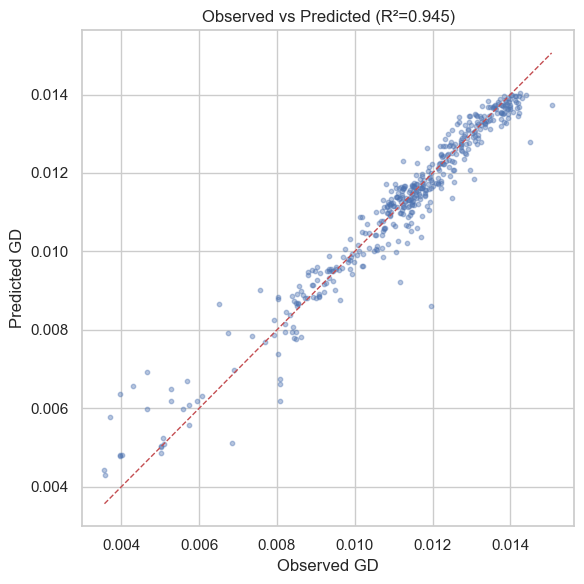

In [87]:
fig, ax = plt.subplots(figsize = (6,6))
ax.scatter(y_test, y_pred, alpha=0.4, s = 10)
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
ax.plot(lims, lims, 'r--' , linewidth=1)
ax.set_xlabel("Observed GD")
ax.set_ylabel("Predicted GD")
ax.set_title(f"Observed vs Predicted (R²={r2:.3f})")
plt.tight_layout()
plt.show()

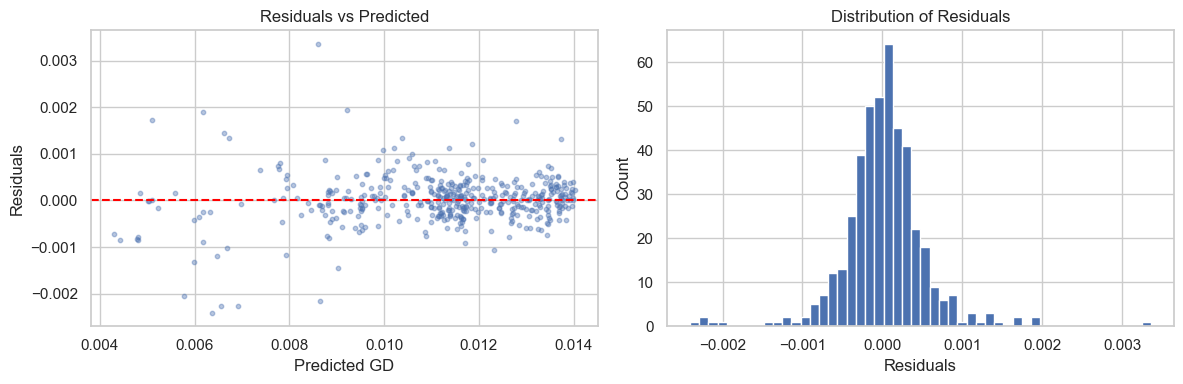

In [88]:
residuals = y_test - y_pred

fig, axes = plt.subplots(1,2, figsize = (12,4))

axes[0].scatter(y_pred, residuals, alpha=0.4, s=10)
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_xlabel("Predicted GD")
axes[0].set_ylabel("Residuals") 
axes[0].set_title("Residuals vs Predicted")

axes[1].hist(residuals, bins=50, edgecolor='white')
axes[1].set_xlabel("Residuals") 
axes[1].set_ylabel("Count")
axes[1].set_title("Distribution of Residuals")

plt.tight_layout()
plt.show()

### Feature importances van gefitte rf

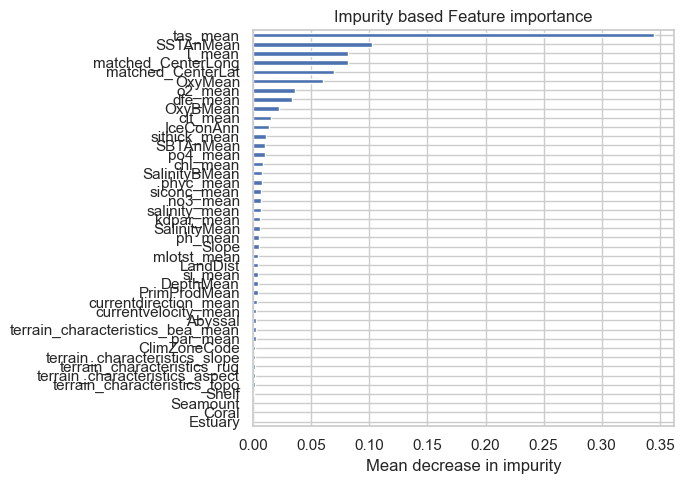

In [89]:
imp = pd.Series(rf.feature_importances_, index=feature_cols).sort_values()

fig, ax = plt.subplots(figsize=(7,5))
imp.plot.barh(ax=ax)
ax.set_xlabel("Mean decrease in impurity")
ax.set_title("Impurity based Feature importance")
plt.tight_layout()
plt.show()

### Spatiale crossvalidatie

In [90]:
lat = df_merge.loc[df_model.index, "lat_deg"]
lon = df_merge.loc[df_model.index, "long_deg"]
lat_bin = pd.cut(lat, bins = np.arange(-90, 91,10), labels = False)
lon_bin = pd.cut(lon, bins = np.arange(-180, 181,10), labels = False)
spatial_blocks = lat_bin.astype(str) + "_" + lon_bin.astype(str)

print(f"\nSpatial blocks (10°x10° grid): {spatial_blocks.nunique()} unique blocks")

gkf = GroupKFold(n_splits=5)
spatial_cv = cross_val_score(
    rf, X, y, cv = gkf, groups = spatial_blocks, scoring= "r2", n_jobs = 1,
)
print("Spatial 5 fold VC R² scores:", np.round(spatial_cv, 4))
print(f"Mean R²: {spatial_cv.mean():.4f} ± {spatial_cv.std():.4f}")


Spatial blocks (10°x10° grid): 422 unique blocks
Spatial 5 fold VC R² scores: [0.9204 0.9353 0.9196 0.9181 0.9492]
Mean R²: 0.9285 ± 0.0121


## Model met minder variabelen

Dit model bevat enkel variabelen van Bio-ORACLE. Daarnaast worden de variabelen die niet beschikbaar zijn in de toekomst ook verwijderd. Op dit model wordt ook dimensionaliteitsreductie uitgevoerd.

Dimensionaliteit reduceren
--> uitkijken voor bias

### Dataframe met enkel Bio-ORACLE

In [4]:
df_bio = df_biooracle
df_bio.columns

Index(['marine_species_richness', 'PD', 'co1_genetic_diversity_mean',
       'long_deg', 'lat_deg', 'chl_max', 'chl_mean', 'chl_min', 'clt_max',
       'clt_mean', 'clt_min', 'currentdirection_max', 'currentdirection_mean',
       'currentdirection_min', 'currentvelocity_ltmax', 'currentvelocity_max',
       'currentvelocity_mean', 'currentvelocity_min', 'dfe_max', 'dfe_mean',
       'dfe_min', 'kdpar_max', 'kdpar_mean', 'kdpar_min', 'mlotst_max',
       'mlotst_mean', 'mlotst_min', 'no3_max', 'no3_mean', 'no3_min', 'o2_max',
       'o2_mean', 'o2_min', 'par_mean', 'par_min', 'phyc_max', 'phyc_mean',
       'phyc_min', 'ph_max', 'ph_mean', 'ph_min', 'po4_max', 'po4_mean',
       'po4_min', 'salinity_ltmax', 'salinity_ltmin', 'salinity_max',
       'salinity_mean', 'salinity_min', 'salinity_range', 'siconc_max',
       'siconc_mean', 'siconc_min', 'sithick_max', 'sithick_mean',
       'sithick_min', 'si_max', 'si_mean', 'si_min', 'tas_max', 'tas_mean',
       'tas_min', 'terrain_charact

Data verwijderen die onnodig is: andere biodiversiteitsmaten, enkel gemiddeldes overhouden

In [5]:
cols_to_drop = (df_bio.filter(regex=r'(?i)(min|max|range)').columns.tolist() + ["PD", "marine_species_richness"])
df_bio = df_bio.drop(cols_to_drop, axis = 1)

df_bio.columns

Index(['co1_genetic_diversity_mean', 'long_deg', 'lat_deg', 'chl_mean',
       'clt_mean', 'currentdirection_mean', 'currentvelocity_mean', 'dfe_mean',
       'kdpar_mean', 'mlotst_mean', 'no3_mean', 'o2_mean', 'par_mean',
       'phyc_mean', 'ph_mean', 'po4_mean', 'salinity_mean', 'siconc_mean',
       'sithick_mean', 'si_mean', 'tas_mean', 'terrain_characteristics_aspect',
       'terrain_characteristics_bea_mean', 'terrain_characteristics_rug',
       'terrain_characteristics_slope', 'terrain_characteristics_topo',
       'T_mean'],
      dtype='object')

Variabelen verwijderen die niet beschikbaar zijn in de toekomst

In [6]:
cols_to_drop = (df_bio.filter(regex=r'(?i)(min|max|range)').columns.tolist() + ["kdpar_mean", "par_mean", "terrain_characteristics_aspect", "terrain_characteristics_bea_mean", "terrain_characteristics_rug", "terrain_characteristics_slope", "terrain_characteristics_topo"])
df_bio = df_bio.drop(cols_to_drop, axis = 1)

df_bio.columns

Index(['co1_genetic_diversity_mean', 'long_deg', 'lat_deg', 'chl_mean',
       'clt_mean', 'currentdirection_mean', 'currentvelocity_mean', 'dfe_mean',
       'mlotst_mean', 'no3_mean', 'o2_mean', 'phyc_mean', 'ph_mean',
       'po4_mean', 'salinity_mean', 'siconc_mean', 'sithick_mean', 'si_mean',
       'tas_mean', 'T_mean'],
      dtype='object')

In [7]:
target_red = "co1_genetic_diversity_mean" # Geselecteerde biodiversiteitsmaat om te voorspellen.
feature_cols_red = df_bio.columns.drop(["long_deg", "lat_deg", "co1_genetic_diversity_mean"]).tolist()

df_red = df_bio[[target_red] + feature_cols_red].copy()
print(f"Shape before cleaning: {df_red.shape}")
df_red.describe()

Shape before cleaning: (2452, 18)


,co1_genetic_diversity_mean,chl_mean,clt_mean,currentdirection_mean,currentvelocity_mean,dfe_mean,mlotst_mean,no3_mean,o2_mean,phyc_mean,ph_mean,po4_mean,salinity_mean,siconc_mean,sithick_mean,si_mean,tas_mean,T_mean
count,2452.000000,2217.000000,2217.000000,2217.000000,2217.000000,2217.000000,2217.000000,2217.000000,2217.000000,2217.000000,2217.000000,2217.000000,2217.000000,2217.000000,2217.000000,2217.000000,2217.000000,2217.000000
mean,0.011101,0.259398,0.447101,152.689401,0.096974,0.000404,48.266381,7.874852,257.423756,1.538574,8.043805,0.673196,34.520979,0.059461,0.070197,14.698095,14.624145,16.382824
std,0.002254,0.215264,0.186835,80.485733,0.096603,0.000829,28.577804,10.287690,53.447055,0.745757,0.025790,0.700528,1.583589,0.173575,0.215610,26.476457,11.465120,10.565343
min,0.003430,0.043151,0.027449,8.444567,0.001367,0.000005,6.990705,0.000422,197.984285,0.554283,7.793579,0.000169,3.213432,0.000000,0.000000,0.656868,-16.241398,-1.838033
25%,0.009949,0.105136,0.271776,74.841409,0.036148,0.000070,29.868310,0.020503,208.600594,1.213635,8.033113,0.090502,33.910668,0.000000,0.000000,1.594731,5.300397,6.396754
50%,0.011438,0.244400,0.450085,138.466769,0.068392,0.000143,41.403713,2.020931,235.609703,1.444429,8.044218,0.381472,34.541424,0.000000,0.000000,2.670603,17.737980,19.306662
75%,0.012741,0.346993,0.613930,233.689689,0.125637,0.000330,56.961308,15.241677,305.790494,1.622265,8.056951,1.198416,35.364977,0.000000,0.000000,13.881882,25.288107,26.387225
max,0.015409,3.750575,0.785068,315.692114,1.121662,0.009292,199.046201,36.047286,387.724233,13.682373,8.141021,2.234311,38.747336,0.963429,1.794409,121.972284,28.490869,30.261832


Hier nog eens opnieuw de missende waarden verwijderen, want df is weer gemaakt op basis van de kolommen waar die waarden nog niet waren verwijderd. 

In [8]:
df_red.replace(-9999.0, np.nan, inplace=True)
df_red.replace(-9999, np.nan, inplace=True)

missing = df_red.isna().sum()
print("Missende waarden per kolom:\n")
print(missing[missing > 0])

df_red.dropna(inplace=True)
print(f"\nShape after dropping rows with NaN: {df_red.shape}")

Missende waarden per kolom:

chl_mean                 235
clt_mean                 235
currentdirection_mean    235
currentvelocity_mean     235
dfe_mean                 235
mlotst_mean              235
no3_mean                 235
o2_mean                  235
phyc_mean                235
ph_mean                  235
po4_mean                 235
salinity_mean            235
siconc_mean              235
sithick_mean             235
si_mean                  235
tas_mean                 235
T_mean                   235
dtype: int64

Shape after dropping rows with NaN: (2217, 18)


In [14]:
print(X.isna().sum().sort_values(ascending=False).head(10))

NameError: name 'X' is not defined

In [10]:
X_red = df_red[feature_cols_red]
y_red = df_red[target_red]

### Recursive feature elimination 


RMSE en spatiale cross validatie

Als markdown

from sklearn.feature_selection import RFECV

#### Random Forest
estimator = RandomForestRegressor(
    n_estimators=500,
    max_depth=20,
    min_samples_leaf=10,
    random_state=42,
    n_jobs=-1
)

#### RFECV met spatial CV + RMSE
selector = RFECV(
    estimator,
    step=1,
    cv=gkf,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

selector.fit(X_red, y_red, groups=spatial_blocks)

print(f"Optimal number of features: {selector.n_features_}")

selected_features_RFECV = X.columns[selector.support_]
print("Selected features:", list(selected_features_RFECV))

### Dataset met geselecteerde features

In [ ]:
selected_features_RFECV = [ # Dit zijn de variabelen die we hier selecteren om de biodiversiteit te voorspellen.
    "chl_mean",      # variabelen kiezen die invloed gaan hebben op de biodiversiteit  
    "clt_mean",  
    "dfe_mean",      
    "kdpar_mean",
    "mlotst_mean",
    "no3_mean",
    "o2_mean",
    "par_mean",
    "phyc_mean",
    "ph_mean",
    "po4_mean",
    "salinity_mean",
    "si_mean",
    "sithick_mean",
    "tas_mean",
    "terrain_characteristics_bea_mean",
    "T_mean", 
    "DepthMean",
    "LandDist",
    "Slope",
    "Abyssal",
]

### Data splitten in training en test set

In [ ]:
X_selected = X_red[selected_features_RFECV]
y_selected = y_red

X_train_selected, X_test_selected, y_train_selected, y_test_selected = train_test_split(
    X_selected, y_selected, test_size = 0.2, random_state = 2026
)

print(f"Training set: {X_train_selected.shape[0]}")
print(f"Test set: {X_test_selected.shape[0]}")

Training set: 1760
Test set: 441


### Fitten van een rf model op training set met enkel geselecteerde features

In [1]:

rf_selected_RFECV = RandomForestRegressor(
    n_estimators=800,
    max_depth=20,
    min_samples_leaf=1,
    random_state=42,
    n_jobs=-1
)

rf_selected_RFECV.fit(X_train_selected, y_train_selected)

# Feature importances
imp = pd.Series(
    rf_selected_RFECV.feature_importances_,
    index=selected_features_RFECV
).sort_values()

print(imp)

NameError: name 'RandomForestRegressor' is not defined

### Hyperparameters optimaliseren

from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(random_state=42)

# de hyperparameters optimaliseren 
param_grid = {
    "n_estimators": [200, 500, 800],
    "max_depth": [10, 20, 30, None],
    "min_samples_leaf": [1, 5, 10],
    "max_features": ["sqrt", 0.3, 0.5]
}

grid = GridSearchCV(
    rf,
    param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

grid.fit(X_train_selected, y_train_selected)

print(grid.best_params_)

{'max_depth': 20, 'max_features': 0.5, 'min_samples_leaf': 1, 'n_estimators': 800}


plt.plot(range(1, len(selector.cv_results_["mean_test_score"]) + 1),
         -selector.cv_results_["mean_test_score"])

plt.xlabel("Number of features")
plt.ylabel("RMSE")
plt.title("RFECV Feature Selection")
plt.show()

### Evalueren rf op training en test set

In [ ]:
y_pred_sel = rf_selected_RFECV.predict(X_test_selected)

r2_train_sel = rf_selected_RFECV.score(X_train_selected, y_train_selected)
rmse_sel = np.sqrt(mean_squared_error(y_test_selected, y_pred_sel))
mae_sel = mean_absolute_error(y_test_selected, y_pred_sel)
r2_sel = r2_score(y_test_selected, y_pred_sel)

print(f"Train R²: {r2_train_sel:.4f}")
print(f"Test R²: {r2_sel:.4f}")
print(f"RMSE: {rmse_sel:.4f}")
print(f"MAE: {mae_sel:.4f}")
print(f"\nTrain-test gap: {r2_train_sel - r2_sel:.4f}")

Train R²: 0.9893
Test R²: 0.9900
RMSE: 0.0002
MAE: 0.0001

Train-test gap: -0.0007


### Visualisatie 

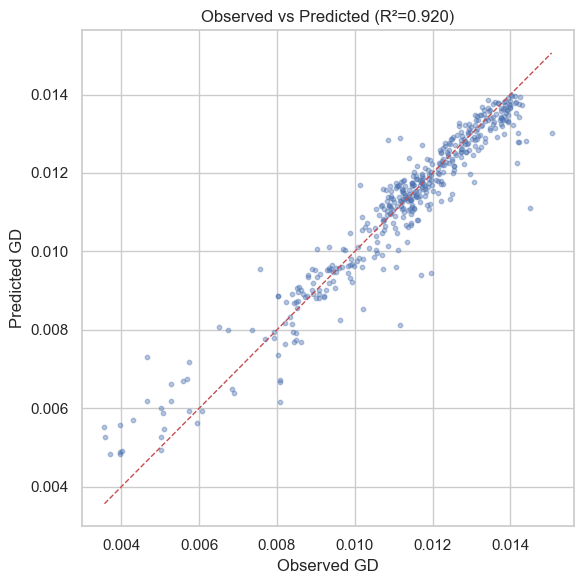

In [ ]:
fig, ax = plt.subplots(figsize = (6,6))
ax.scatter(y_test_selected, y_pred, alpha=0.4, s = 10)
lims = [min(y_test_selected.min(), y_pred.min()), max(y_test_selected.max(), y_pred.max())]
ax.plot(lims, lims, 'r--' , linewidth=1)
ax.set_xlabel("Observed GD")
ax.set_ylabel("Predicted GD")
ax.set_title(f"Observed vs Predicted (R²={r2:.3f})")
plt.tight_layout()
plt.show()

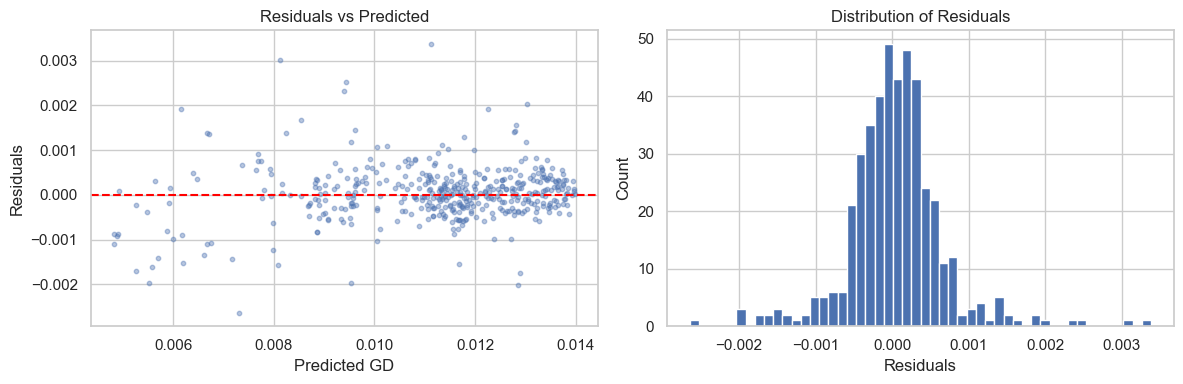

In [ ]:
residuals_red = y_test_selected - y_pred

fig, axes = plt.subplots(1,2, figsize = (12,4))

axes[0].scatter(y_pred, residuals_red, alpha=0.4, s=10)
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_xlabel("Predicted GD")
axes[0].set_ylabel("Residuals") 
axes[0].set_title("Residuals vs Predicted")

axes[1].hist(residuals_red, bins=50, edgecolor='white')
axes[1].set_xlabel("Residuals") 
axes[1].set_ylabel("Count")
axes[1].set_title("Distribution of Residuals")

plt.tight_layout()
plt.show()

### Feature importance

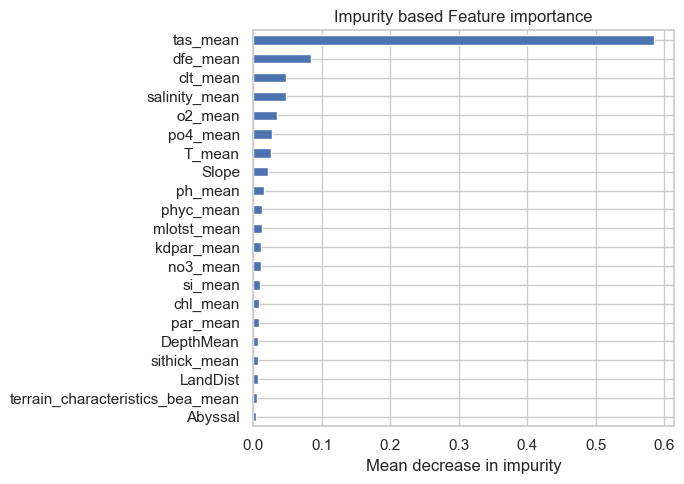

In [ ]:
imp_red = pd.Series(rf_selected_RFECV.feature_importances_, index=selected_features_RFECV).sort_values()

fig, ax = plt.subplots(figsize=(7,5))
imp_red.plot.barh(ax=ax)
ax.set_xlabel("Mean decrease in impurity")
ax.set_title("Impurity based Feature importance")
plt.tight_layout()
plt.show()

## Toekomst

### SSP 1.1.9

In [ ]:
toekomst_SSP119 = pd.read_csv("GD_2050-60_SSP119.csv")
X_future = toekomst_SSP119[X_train_selected.columns] #waarom X_train en niet gewoon X?
GD_toekomst = rf_selected_RFECV.predict(X_future)

In [ ]:
toekomst_SSP119["GD"] = GD_toekomst
toekomst_SSP119 .head()

,Unnamed: 0,chl_mean,clt_mean,dfe_mean,mlotst_mean,no3_mean,o2_mean,phyc_mean,ph_mean,po4_mean,...,long_deg,lat_deg,DepthMean,LandDist,Slope,Abyssal,par_mean,kdpar_mean,terrain_characteristics_bea_mean,GD
0,0,0.269789,0.689485,0.000391,61.532763,30.799999,314.002378,1.237505,7.970945,2.152274,...,-171.74579,-71.23536,3998,636,730.228795,263.361205,37.450932,0.060146,-3936.972168,0.007011
1,1,0.282911,0.700666,0.000376,63.236088,30.954686,315.845510,1.337427,7.972867,2.166582,...,-167.88679,-71.23536,4079,742,0.000000,993.590000,29.998841,0.062998,-4093.388916,0.006897
2,2,0.270978,0.703526,0.000368,63.562959,30.953779,315.316479,1.259565,7.973096,2.168482,...,-164.02779,-71.23536,4185,708,0.000000,993.590000,32.604841,0.072465,-4160.611328,0.007072
3,3,0.294444,0.697370,0.000348,59.205664,30.785960,318.284476,1.335023,7.976109,2.159415,...,-160.16879,-71.23536,4231,661,0.000000,993.590000,31.006588,0.067391,-4305.361328,0.007111
4,4,0.299291,0.692536,0.000343,60.567262,30.756873,317.223787,1.358980,7.975836,2.158386,...,-156.30979,-71.23536,4322,608,0.000000,993.590000,33.850906,0.066070,-4353.527832,0.007053


Distributie GD

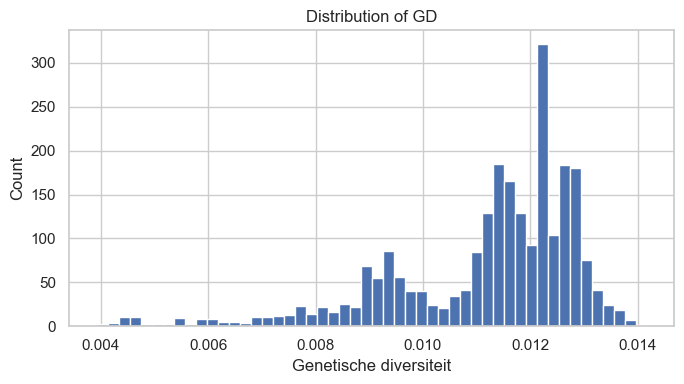

In [ ]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(toekomst_SSP119["GD"], bins=50, edgecolor="white")
ax.set_xlabel("Genetische diversiteit")
ax.set_ylabel("Count")
ax.set_title("Distribution of GD")
plt.tight_layout()
plt.show()

Kaart

In [ ]:
import plotly.express as px
import plotly.io as pio

In [ ]:
fig_SSP119 = px.scatter_geo(
    toekomst_SSP119,
    lat="lat_deg",
    lon="long_deg",
    color="GD",   # kleurt de punten op basis van biodiversiteit
    hover_name="GD",  
    projection="natural earth",    # mooie wereldkaart
    title = "Genetische diversiteit"
)

fig_SSP119.show()

ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed

### SSP 1.2.6

In [ ]:
toekomst_SSP126 = pd.read_csv("GD_2050-60_SSP126.csv")
X_future = toekomst_SSP126[X_train_selected.columns] #waarom X_train en niet gewoon X?
GD_toekomst = rf_selected_RFECV.predict(X_future)

In [ ]:
toekomst_SSP126["GD"] = GD_toekomst
toekomst_SSP126 .head()

,Unnamed: 0,chl_mean,clt_mean,dfe_mean,mlotst_mean,no3_mean,o2_mean,phyc_mean,ph_mean,po4_mean,...,long_deg,lat_deg,DepthMean,LandDist,Slope,Abyssal,par_mean,kdpar_mean,terrain_characteristics_bea_mean,GD
0,0,0.264738,0.685382,0.000333,59.873447,30.339450,317.311825,1.462501,7.956235,2.127915,...,-171.74579,-71.23536,3998,636,730.228795,263.361205,37.450932,0.060146,-3936.972168,0.007077
1,1,0.279545,0.698337,0.000307,59.631997,30.320359,319.230605,1.453052,7.957836,2.126779,...,-167.88679,-71.23536,4079,742,0.000000,993.590000,29.998841,0.062998,-4093.388916,0.006803
2,2,0.272520,0.703587,0.000304,52.292932,30.218967,318.271827,1.395905,7.957967,2.119736,...,-164.02779,-71.23536,4185,708,0.000000,993.590000,32.604841,0.072465,-4160.611328,0.006818
3,3,0.297756,0.698612,0.000315,31.966103,29.987898,320.985091,1.454854,7.960676,2.105292,...,-160.16879,-71.23536,4231,661,0.000000,993.590000,31.006588,0.067391,-4305.361328,0.006904
4,4,0.304306,0.693806,0.000356,38.777512,29.912720,319.709665,1.456157,7.960031,2.100458,...,-156.30979,-71.23536,4322,608,0.000000,993.590000,33.850906,0.066070,-4353.527832,0.006906


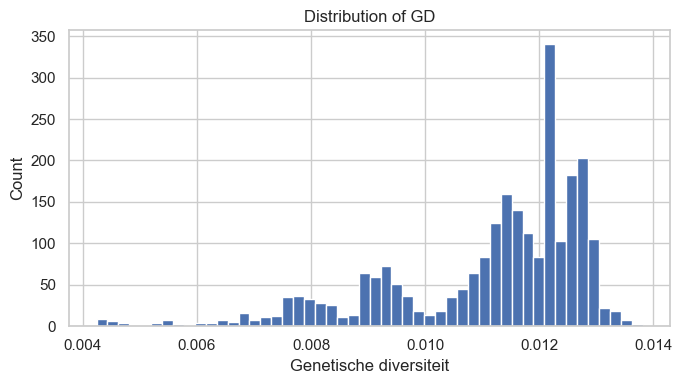

In [ ]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(toekomst_SSP126["GD"], bins=50, edgecolor="white")
ax.set_xlabel("Genetische diversiteit")
ax.set_ylabel("Count")
ax.set_title("Distribution of GD")
plt.tight_layout()
plt.show()

In [ ]:
fig_SSP126 = px.scatter_geo(
    toekomst_SSP126,
    lat="lat_deg",
    lon="long_deg",
    color="GD",   # kleurt de punten op basis van biodiversiteit
    hover_name="GD",  
    projection="natural earth",    # mooie wereldkaart
    title = "Genetische diversiteit"
)

fig_SSP126.show()

ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed